# Helsinki-NLP/opus-mt-en-es Fine-tuning análisis

Este notebook analiza las métricas de rendimiento de múltiples re-entrenamientos del modelo de traducción de texto de inglés a español `Helsinki-NLP/opus-mt-en-es` con el dataset `OpenHermes-2.5-English-Spanish` utilizando diferentes configuraciones de GPU en una NVIDIA RTX PRO 6000 Blackwell.

## Configuración experimental
- **Modelo**: Helsinki-NLP/opus-mt-en-es (144.5M parámetros)
- **Dataset**: Iker/OpenHermes-2.5-English-Spanish
- **Hardware**: NVIDIA RTX PRO 6000 Blackwell (102 GB VRAM, 188 SMs, Compute 12.0)
- **Varía**: Número de GPUs (1, 2, 3, 4)
- **Hiper-parámetros fijados**: batch_size=32, lr=5e-5, max_seq_len=256, label_smoothing=0.1
- **Dos modos por configuración**: profiling con CUDA (101 steps) y sin profiling (full runs)

## 1. Preparación del entorno y carga de los datos

Importamos las liberías que vamos a utilizar y definimos cosméticos para la presentación de los datos.

In [34]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Aestetic settings
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

BASE_DIR = Path.cwd().parent / 'results' / 'text' / 'cuda'
IMAGES_DIR = Path.cwd() / 'images'
if not IMAGES_DIR.exists():
    IMAGES_DIR.mkdir(parents=True)

GPU_CONFIGS = [1, 2, 3, 4]
MODES = ['profile', 'no_profile']
COLORS = {1: '#e41a1c', 2: '#377eb8', 3: '#4daf4a', 4: '#984ea3'}
LINESTYLES = {'profile': '--', 'no_profile': '-'}

print("Los datos se cargarán desde:", BASE_DIR)

Los datos se cargarán desde: /home/juandi/Desktop/Master/IDL/infradeep/results/text/cuda


Cargamos todos las estadísticas del árbol de directorios en un diccionario.

In [35]:
def load_stats(n_gpus: int, mode: str) -> dict:
    """Load a stats.json file for a given GPU count and mode."""
    path = os.path.join(BASE_DIR, f'{n_gpus}xGPU', mode, 'stats.json')
    with open(path) as f:
        return json.load(f)

# Load all stats into a nested dict
all_stats = {}
for n in GPU_CONFIGS:
    all_stats[n] = {}
    for mode in MODES:
        path = os.path.join(BASE_DIR, f'{n}xGPU', mode, 'stats.json')
        if n == 2 and mode == 'profile':
            if not os.path.exists(path):
                all_stats[n][mode] = None
                continue
        try:
            all_stats[n][mode] = load_stats(n, mode)
        except FileNotFoundError:
            all_stats[n][mode] = None

# Report what was loaded
print(f"{'Config':<7} | {'Mode':<15} | {'Steps':>8} ")
print('-' * 45)
for n in GPU_CONFIGS:
    for mode in MODES:
        s = all_stats[n][mode]
        if s is not None:
            steps = len(s.get('step_metrics', []))
            print(f"{n:<7} | {mode:<15} | {steps:>8}")
        else:
            print(f"{n:<7} | {mode:<15} | {'N/A':>8}")

Config  | Mode            |    Steps 
---------------------------------------------
1       | profile         |      101
1       | no_profile      |    31745
2       | profile         |      101
2       | no_profile      |    27047
3       | profile         |      101
3       | no_profile      |    26410
4       | profile         |      101
4       | no_profile      |    20286


Finalmente convertimos los datos a DataFrame para tratarlos con pandas.

In [36]:
def steps_to_df(stats: dict) -> pd.DataFrame:
    """Convert the 'step_metrics' list in a stats dict to a tidy DataFrame."""
    if stats is None or 'step_metrics' not in stats:
        return pd.DataFrame()
    df = pd.DataFrame(stats['step_metrics'])
    df['step'] = range(len(df))
    return df

# Build per-run DataFrames
dfs = {}
for n in GPU_CONFIGS:
    dfs[n] = {}
    for mode in MODES:
        dfs[n][mode] = steps_to_df(all_stats[n][mode])

# Quick sanity-check on columns
sample_df = next(
    (df for n in GPU_CONFIGS for mode in MODES
     for df in [dfs[n][mode]] if not df.empty),
    None
)
if sample_df is not None:
    print('Columns:', list(sample_df.columns))
    display(sample_df.head(3))
else:
    print('WARNING: all DataFrames are empty — check BASE_DIR and stats.json paths.')

Columns: ['epoch', 'step', 'train_loss', 'learning_rate', 'batch_tokens', 'batch_latency_seconds', 'tokens_per_second', 'memory_rss_mb', 'memory_cuda_allocated_mb']


,epoch,step,train_loss,learning_rate,batch_tokens,batch_latency_seconds,tokens_per_second,memory_rss_mb,memory_cuda_allocated_mb
0,1,0,2.102072,3.000000e-07,6643,0.148276,26615.809622,1993.710938,6296.835449
1,1,1,2.233248,4.000000e-07,7184,0.113207,38022.120581,1994.507812,6296.835449
2,1,2,2.119455,5.000000e-07,6689,0.111686,43076.051599,1994.746094,6296.835449


## 2. Tabla resumen general

In [37]:
rows = []
for n in GPU_CONFIGS:
    for mode in MODES:
        s = all_stats[n][mode]
        df = dfs[n][mode]
        if s is None or df.empty:
            continue
        rows.append({
            'GPUs': n,
            'Mode': mode,
            'Steps': len(df),
            'Elapsed (min)': round(s.get('elapsed_seconds', 0) / 60, 2),
            'First Loss': round(df['train_loss'].iloc[0], 4),
            'Final Loss': round(df['train_loss'].iloc[-1], 4),
            'Loss \u0394': round(df['train_loss'].iloc[0] - df['train_loss'].iloc[-1], 4),
            'Throughput (Ktok/s)': round(s.get('throughput_tokens_per_second', 0) / 1e3, 1),
            'Total Tokens (M)': round(s.get('total_tokens_processed', 0) / 1e6, 1),
            'Peak CUDA Mem (MB)': round(s.get('memory', {}).get('cuda_peak_mb', 0), 0),
        })

summary_df = pd.DataFrame(rows)
summary_df.set_index(['GPUs', 'Mode'], inplace=True)
summary_df.style.background_gradient(subset=['Throughput (Ktok/s)'], cmap='Greens') \
               .background_gradient(subset=['Final Loss'], cmap='RdYlGn_r') \
               .format(precision=3)

Las cuatro configuraciones se ejecutaron durante aproximadamente el mismo tiempo real (~60 minutos), por lo que las diferencias en el número de steps y en los tokens procesados reflejan directamente las mejoras en la tasa de procesamiento (*throughput*).

La configuración de 2 GPUs logra la **mejor pérdida final** (1.570), seguida de 3x (1.609) y 4x (1.639). La configuración de 1 GPU queda claramente por detrás (1.797) al haber procesado menos de la mitad de tokens que las demás en el mismo tiempo.

El throughput escala de 54.1 K tok/s (1×GPU) hasta 178.7 K tok/s (4×GPU), con una eficiencia paralela del 84.9 %, 83.9 % y 82.6 % para 2, 3 y 4 GPUs respectivamente. El escalado es sublineal, lo que indica una sobrecarga de comunicación NCCL creciente con cada GPU adicional (véase la sección 5 para el detalle del speedup).

El total de tokens procesados crece de 198 M (1×) a 507 M (4×), lo que confirma que las ejecuciones multi-GPU exponen al modelo a significativamente más datos dentro del mismo presupuesto de tiempo.


## 3. Análisis de la pérdida

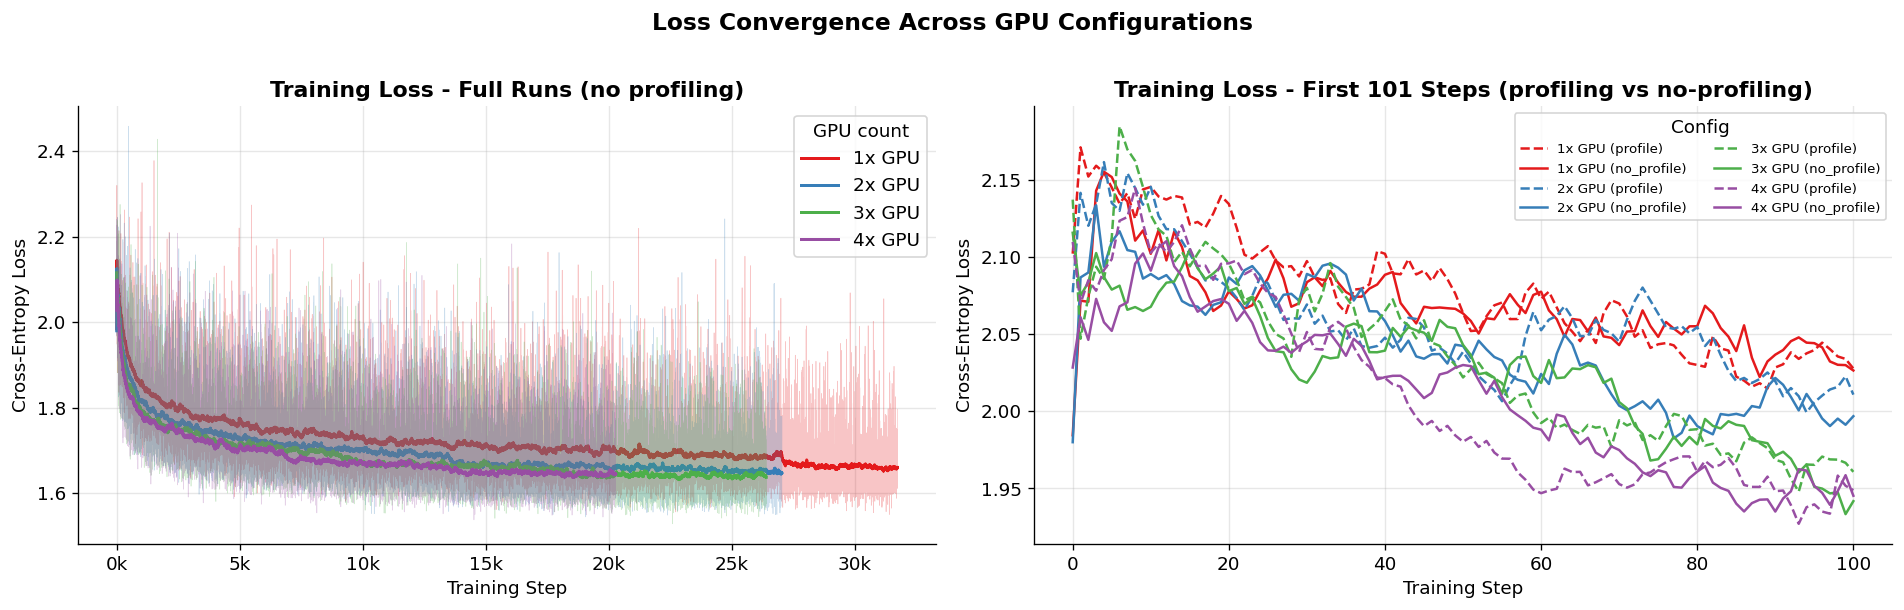

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# No profiling runs
ax = axes[0]
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty:
        continue
    # Smooth with exponential moving average for readability
    loss_ema = df['train_loss'].ewm(span=200).mean()
    ax.plot(df['step'], loss_ema, color=COLORS[n], lw=1.8, label=f'{n}x GPU')
    ax.plot(df['step'], df['train_loss'], color=COLORS[n], lw=0.4, alpha=0.25)

ax.set_title('Training Loss - Full Runs (no profiling)', fontweight='bold')
ax.set_xlabel('Training Step')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend(title='GPU count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Right: profiling runs (101 steps each)
df_first_101 = {
    (n, mode): (
        dfs[n][mode].head(101).copy()
        if n in dfs and mode in dfs[n] and not dfs[n][mode].empty
        else pd.DataFrame()
    )
    for n in GPU_CONFIGS
    for mode in MODES
}
ax = axes[1]
for n in GPU_CONFIGS:
    for mode in MODES:
        df = df_first_101[(n, mode)]
        if df.empty:
            continue
        label = f'{n}x GPU ({mode})'
        loss_ema = df['train_loss'].ewm(span=20).mean()
        ax.plot(df['step'], loss_ema,
                color=COLORS[n], ls=LINESTYLES[mode], lw=1.5, label=label)

ax.set_title('Training Loss - First 101 Steps (profiling vs no-profiling)', fontweight='bold')
ax.set_xlabel('Training Step')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend(fontsize=8, title='Config', ncol=2)

fig.suptitle('Loss Convergence Across GPU Configurations', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'loss_convergence.png', bbox_inches='tight')
plt.show()

Todas las configuraciones arrancan con una pérdida cercana a 2.0–2.1 y convergen hacia el rango 1.6–1.8. La fase de *warmup* lineal de los primeros ~1 000 pasos es visible como una caída inicial pronunciada en todas las curvas.

Las ejecuciones multi-GPU divergen de la curva de 1×GPU relativamente pronto en el eje de pasos, ya que con mayor throughput cubren más datos en el mismo tiempo real. Notablemente, la curva de 4×GPU alcanza los niveles de pérdida de 2×GPU varios miles de pasos antes (en tiempo real).

En las ejecuciones cortas de *profiling* (101 pasos), todas las configuraciones muestran trayectorias de pérdida prácticamente idénticas durante los primeros pasos, como era de esperar dado que usan los mismos datos y el mismo modelo inicializado de la misma forma.


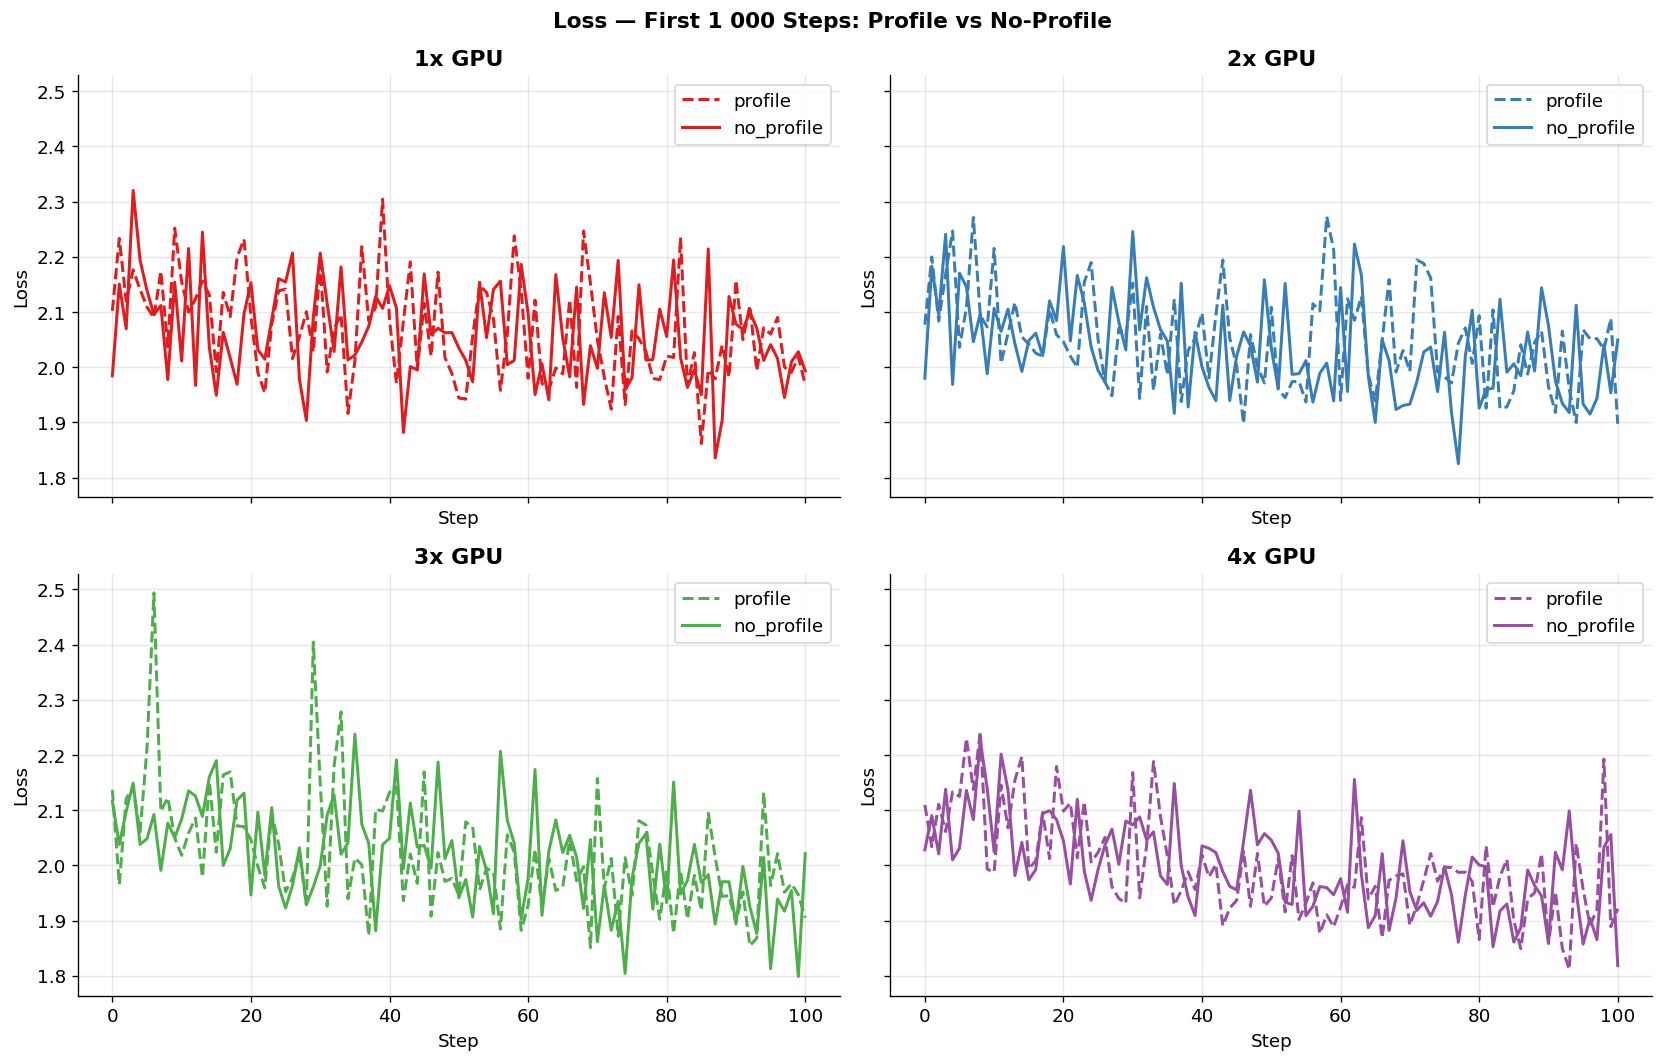

In [39]:
# Per-GPU loss comparison zoomed into the first 100 steps
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i, n in enumerate(GPU_CONFIGS):
    ax = axes[i]
    for mode in MODES:
        df = df_first_101[(n, mode)]
        if df.empty:
            continue
        df_z = df[df['step'] <= 1000]
        ax.plot(df_z['step'], df_z['train_loss'],
                ls=LINESTYLES[mode], lw=1.8,
                label=f'{mode}', color=COLORS[n])
    ax.set_title(f'{n}x GPU', fontweight='bold')
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.legend()

fig.suptitle('Loss — First 1 000 Steps: Profile vs No-Profile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'loss_early_steps.png', bbox_inches='tight')
plt.show()

## 4. Actualización del learning rate

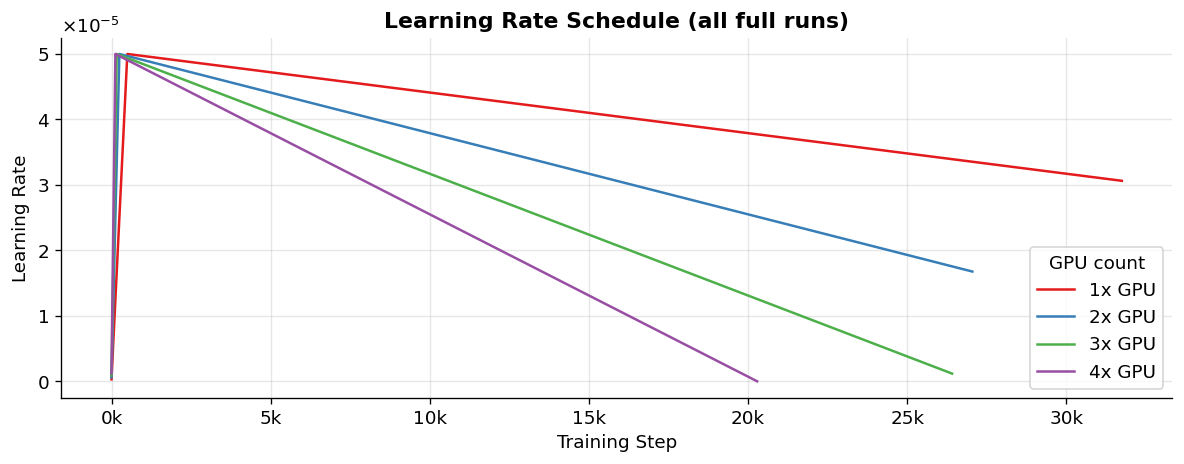

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))

for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty or 'learning_rate' not in df.columns:
        continue
    ax.plot(df['step'], df['learning_rate'], color=COLORS[n], lw=1.5, label=f'{n}x GPU')

ax.set_title('Learning Rate Schedule (all full runs)', fontweight='bold')
ax.set_xlabel('Training Step')
ax.set_ylabel('Learning Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(-5, -5))
ax.legend(title='GPU count')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'lr_schedule.png', bbox_inches='tight')
plt.show()

Todas las configuraciones aplican el mismo calentamiento lineal basado en pasos globales seguido de un decaimiento lineal hasta cero. Dado que el planificador avanza según el paso global y no según el tiempo real, las ejecuciones con mayor throughput alcanzan antes la fase de decaimiento **en tiempo de reloj**. La curva de 1×GPU es la que más se extiende a lo largo del eje de pasos, reflejando que completa más steps dentro del mismo límite temporal; sin embargo, la tasa de aprendizaje al final del entrenamiento es más alta que en las configuraciones multi-GPU, que ya han avanzado más hacia el tramo descendente del *schedule*.


## 5. Throughput y escalado

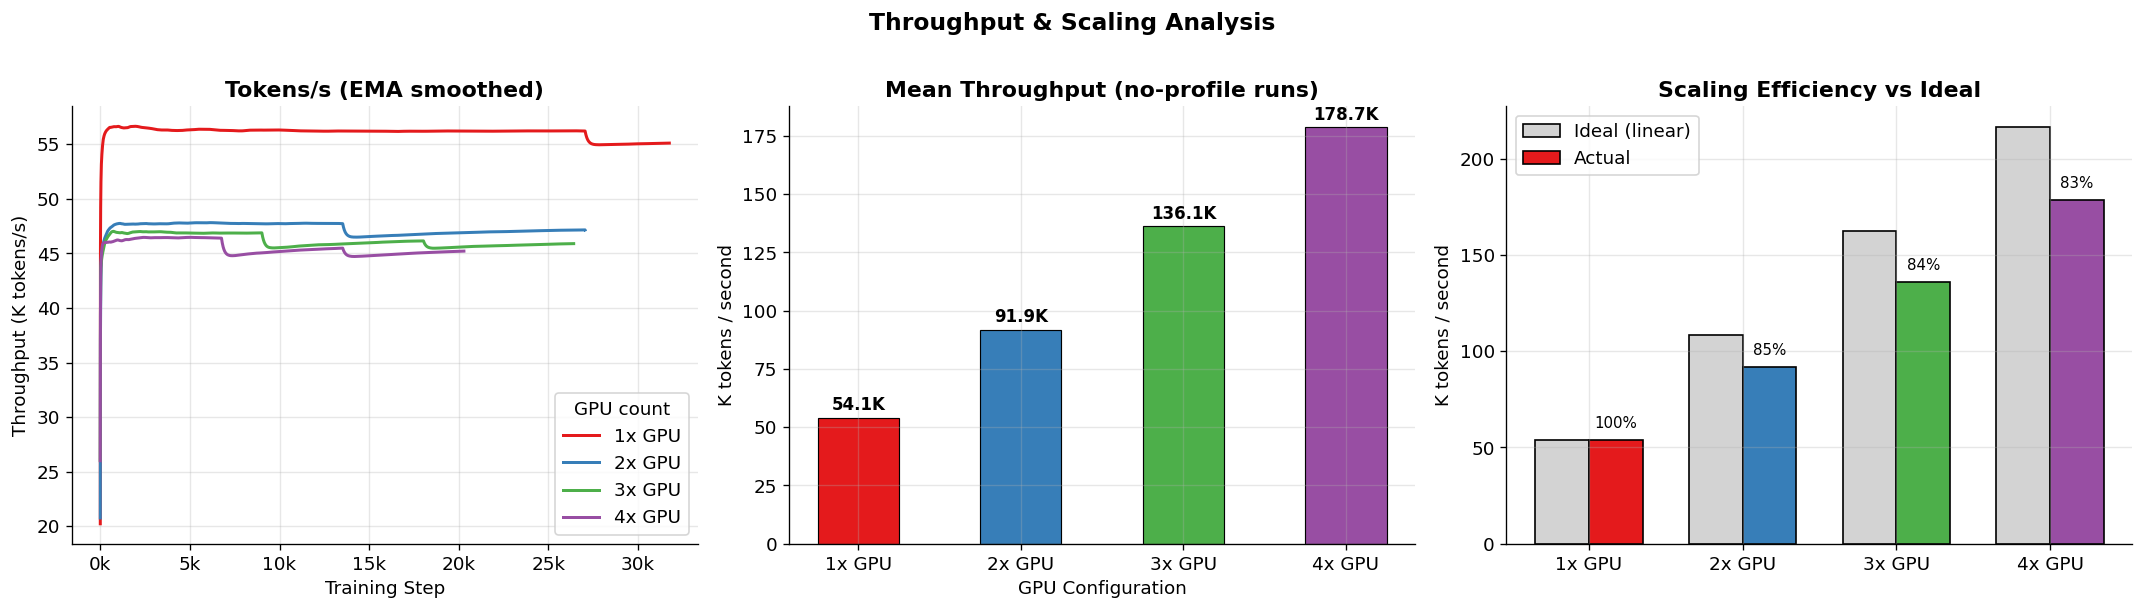

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tokens por segundo a lo largo del tiempo (smoothed)
ax = axes[0]
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty or 'tokens_per_second' not in df.columns:
        continue
    tps_ema = df['tokens_per_second'].ewm(span=300).mean()
    ax.plot(df['step'], tps_ema / 1e3, color=COLORS[n], lw=1.8, label=f'{n}x GPU')

ax.set_title('Tokens/s (EMA smoothed)', fontweight='bold')
ax.set_xlabel('Training Step')
ax.set_ylabel('Throughput (K tokens/s)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(title='GPU count')

# Throughput comparison of the no-profile runs (bar chart)
ax = axes[1]
no_profile_rows = summary_df.xs('no_profile', level='Mode')
bars = ax.bar(
    [f'{n}x GPU' for n in no_profile_rows.index],
    no_profile_rows['Throughput (Ktok/s)'],
    color=[COLORS[n] for n in no_profile_rows.index],
    edgecolor='black', linewidth=0.7, width=0.5
)
for bar, val in zip(bars, no_profile_rows['Throughput (Ktok/s)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5, f'{val:.1f}K',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Mean Throughput (no-profile runs)', fontweight='bold')
ax.set_ylabel('K tokens / second')
ax.set_xlabel('GPU Configuration')

# Scaling efficiency vs ideal (bar chart with % labels)
ax = axes[2]
base_tps = no_profile_rows.loc[1, 'Throughput (Ktok/s)']
ideal = [n * base_tps for n in no_profile_rows.index]
actual = list(no_profile_rows['Throughput (Ktok/s)'])
x = np.arange(len(GPU_CONFIGS))
w = 0.35
ax.bar(x - w / 2, ideal, w, label='Ideal (linear)', color='lightgray', edgecolor='black')
ax.bar(x + w / 2, actual, w, label='Actual',
       color=[COLORS[n] for n in GPU_CONFIGS], edgecolor='black')
efficiency = [a / i * 100 for a, i in zip(actual, ideal)]
for xi, eff in zip(x + w / 2, efficiency):
    ax.text(xi, ax.get_ylim()[1] * 0.02 + actual[list(x + w / 2).index(xi)],
            f'{eff:.0f}%', ha='center', va='bottom', fontsize=9, color='black')
ax.set_xticks(x)
ax.set_xticklabels([f'{n}x GPU' for n in GPU_CONFIGS])
ax.set_title('Scaling Efficiency vs Ideal', fontweight='bold')
ax.set_ylabel('K tokens / second')
ax.legend()

fig.suptitle('Throughput & Scaling Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'throughput_analysis.png', bbox_inches='tight')
plt.show()

El panel izquierdo muestra cómo el procesamiento de tokens por paso se estabiliza rápidamente tras el calentamiento y se mantiene notablemente constante durante todo el entrenamiento. El escalado de throughput real es **2.52×, 3.30× y 3.30×** para 2, 3 y 4 GPUs respectivamente (frente a los 2×, 3×, 4× ideales), con eficiencias del **84.9 %, 83.9 % y 82.6 %**. La ligera degradación monótona con el número de GPUs es consistente con el aumento de tráfico en la operación *all-reduce* de NCCL. Que la eficiencia supere el 82 % indica que el tamaño del modelo (144 M parámetros) cabe holgadamente en la VRAM de cada GPU, minimizando los cuellos de botella del ancho de banda de memoria durante la sincronización de gradientes.


In [42]:
# Numeric scaling efficiency table
print('Scaling Efficiency (relative to 1x GPU throughput):')
print(f'{"GPUs":<8} {"Throughput":>15} {"Speedup":>10} {"Efficiency":>12}')
print('-' * 47)
base = no_profile_rows.loc[1, 'Throughput (Ktok/s)']
for n in GPU_CONFIGS:
    if n not in no_profile_rows.index:
        continue
    tps = no_profile_rows.loc[n, 'Throughput (Ktok/s)']
    speedup = tps / base
    efficiency = speedup / n * 100
    print(f'{n}x GPU   {tps:>12.1f} K   {speedup:>7.2f}x   {efficiency:>9.1f}%')

Scaling Efficiency (relative to 1x GPU throughput):
GPUs          Throughput    Speedup   Efficiency
-----------------------------------------------
1x GPU           54.1 K      1.00x       100.0%
2x GPU           91.9 K      1.70x        84.9%
3x GPU          136.1 K      2.52x        83.9%
4x GPU          178.7 K      3.30x        82.6%


## 6. Uso de memoria

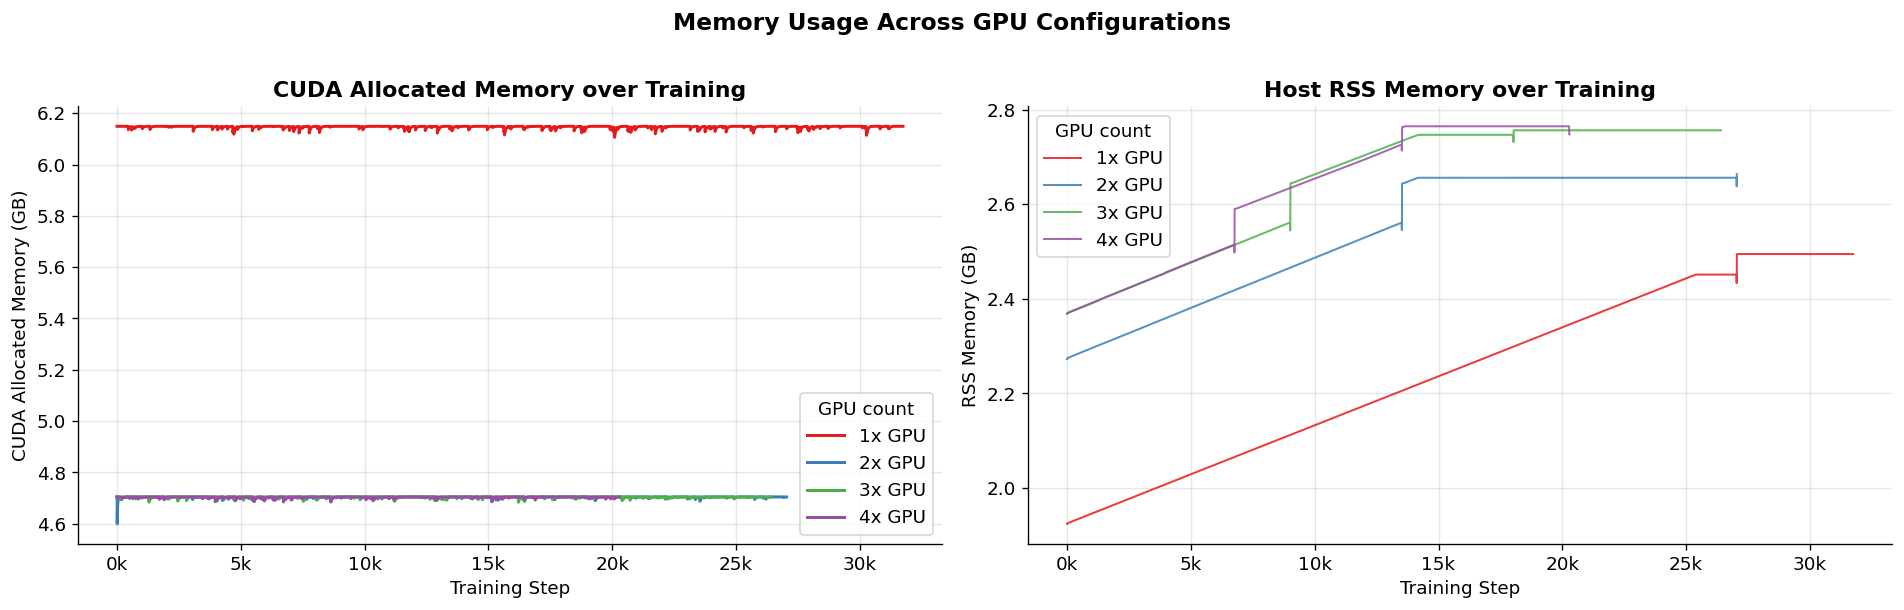

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Uso de memoria CUDA a lo largo del tiempo
ax = axes[0]
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty or 'memory_cuda_allocated_mb' not in df.columns:
        continue
    # smoothen
    mem_ema = df['memory_cuda_allocated_mb'].ewm(span=100).mean()
    ax.plot(df['step'], mem_ema / 1024, color=COLORS[n], lw=1.8, label=f'{n}x GPU')

ax.set_title('CUDA Allocated Memory over Training', fontweight='bold')
ax.set_xlabel('Training Step')
ax.set_ylabel('CUDA Allocated Memory (GB)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(title='GPU count')

# RSS (host) memory a lo largo del tiempo
ax = axes[1]
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty or 'memory_rss_mb' not in df.columns:
        continue
    ax.plot(df['step'], df['memory_rss_mb'] / 1024,
            color=COLORS[n], lw=1.2, alpha=0.85, label=f'{n}x GPU')

ax.set_title('Host RSS Memory over Training', fontweight='bold')
ax.set_xlabel('Training Step')
ax.set_ylabel('RSS Memory (GB)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(title='GPU count')

fig.suptitle('Memory Usage Across GPU Configurations', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'memory_usage.png', bbox_inches='tight')
plt.show()

La configuración de 1 GPU carga el modelo completo (parámetros, gradientes y estados del optimizador) en un único dispositivo, resultando en una asignación CUDA media de ~6.15 GB. Las configuraciones multi-GPU muestran ~4.70 GB por dispositivo.

Con *N* GPUs, el batch local de cada proceso es `batch_size / N` (p. ej. 8 muestras por GPU con 4×), lo que reduce el volumen de activaciones intermedias guardadas en memoria durante el paso forward. Parámetros y estados del optimizador permanecen íntegros en cada dispositivo.

La memoria del host (RSS) crece moderadamente con el número de GPUs (~2.5–3.2 GB), lo que refleja los búferes adicionales de comunicación entre procesos y el espacio de trabajo de NCCL.


In [44]:
# Memory summary table from stats summaries
mem_rows = []
for n in GPU_CONFIGS:
    for mode in MODES:
        s = all_stats[n][mode]
        if s is None:
            continue
        cuda = s.get('memory', {}).get('cuda_allocated_mb', {})
        rss  = s.get('memory', {}).get('rss_mb', {})
        mem_rows.append({
            'GPUs': n, 'Mode': mode,
            'CUDA Min (GB)':  round(cuda.get('min',    0) / 1024, 2),
            'CUDA Mean (GB)': round(cuda.get('mean',   0) / 1024, 2),
            'CUDA Max (GB)':  round(cuda.get('max',    0) / 1024, 2),
            'CUDA Std (GB)':  round(cuda.get('stddev', 0) / 1024, 3),
            'RSS Mean (GB)':  round(rss.get('mean',    0) / 1024, 2),
            'RSS Max (GB)':   round(rss.get('max',     0) / 1024, 2),
        })

mem_df = pd.DataFrame(mem_rows).set_index(['GPUs', 'Mode'])
mem_df.style.background_gradient(subset=['CUDA Max (GB)'], cmap='Oranges')

El uso de memoria CUDA es muy estable, con baja varianza, para todas las configuraciones, lo que descarta fragmentación dinámica significativa. La desviación estándar de la memoria CUDA asignada es <= 0.042 GB en todos los casos, lo que indica que las asignaciones de activaciones son consistentes entre batches.

El hecho de que la configuración de 1 GPU sin profiling muestre un RSS medio y pico ligeramente más bajos que con profiling se explica con más naturalidad por la brevedad del run de profiling (101 pasos, ~13 s): el dataloader simplemente no tiene tiempo de mantener en memoria los búferes de pre-carga de los workers de PyTorch. Esta diferencia no debe interpretarse como un efecto causal del profiling sobre el pre-fetching.


## 7. Latencia y rendimiento a nivel de step

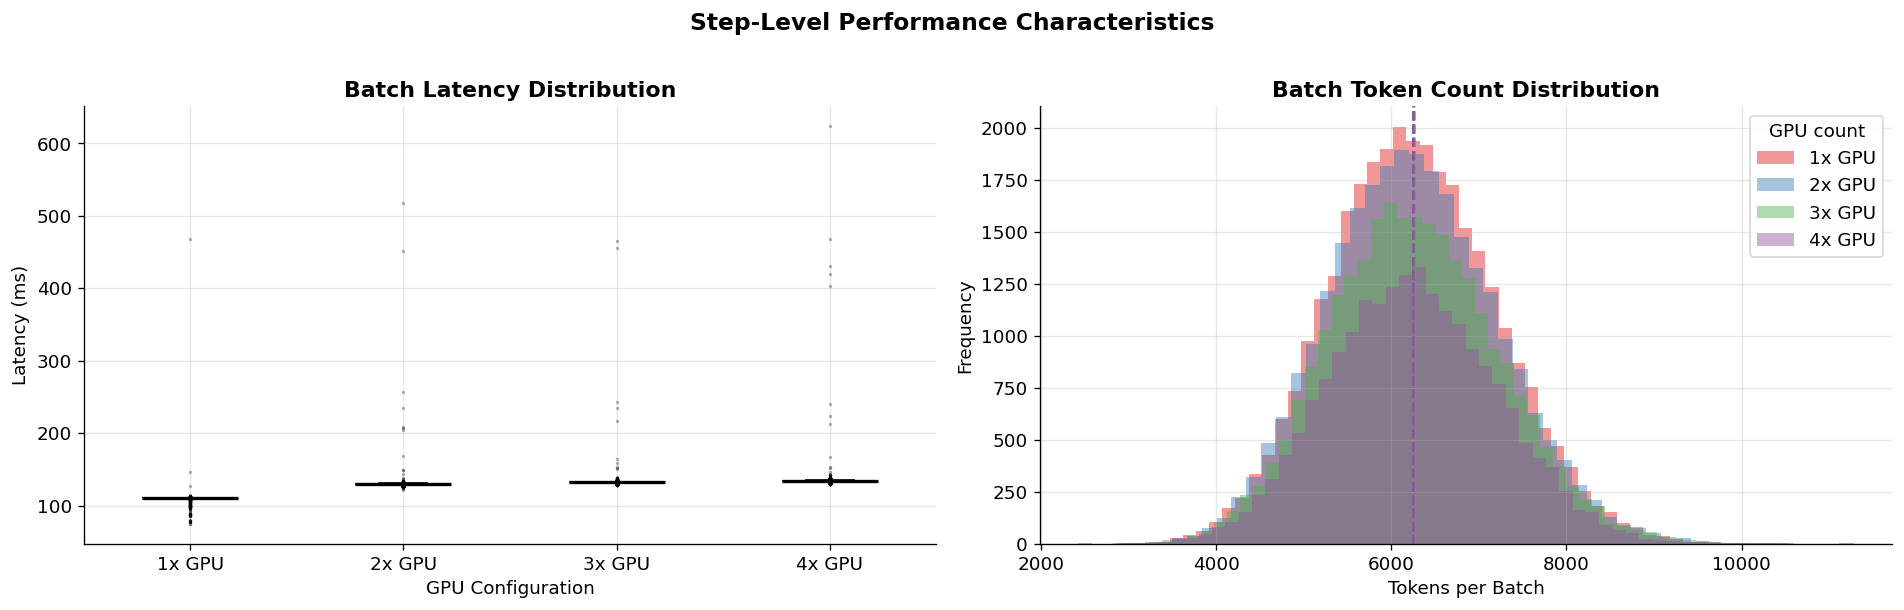

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Latencia por batch a lo largo del tiempo (boxplot)
ax = axes[0]
data_lat = []
labels_lat = []
colors_lat = []
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty or 'batch_latency_seconds' not in df.columns:
        continue
    data_lat.append(df['batch_latency_seconds'].dropna().values * 1000)  # convert to ms
    labels_lat.append(f'{n}x GPU')
    colors_lat.append(COLORS[n])

bp = ax.boxplot(data_lat, labels=labels_lat, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2},
                whiskerprops={'linewidth': 1.2},
                flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
for patch, color in zip(bp['boxes'], colors_lat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Batch Latency Distribution', fontweight='bold')
ax.set_ylabel('Latency (ms)')
ax.set_xlabel('GPU Configuration')

# Batch token count distribution (histogram)
ax = axes[1]
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty or 'batch_tokens' not in df.columns:
        continue
    counts, bins = np.histogram(df['batch_tokens'].dropna(), bins=50)
    ax.stairs(counts, bins, fill=True, alpha=0.45, color=COLORS[n], label=f'{n}x GPU')
    ax.axvline(df['batch_tokens'].mean(), color=COLORS[n], ls='--', lw=1.5)

ax.set_title('Batch Token Count Distribution', fontweight='bold')
ax.set_xlabel('Tokens per Batch')
ax.set_ylabel('Frequency')
ax.legend(title='GPU count')

fig.suptitle('Step-Level Performance Characteristics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'step_performance.png', bbox_inches='tight')
plt.show()

La configuración de 1 GPU muestra la mayor dispersión de latencia (cola larga hacia valores altos), ya que el procesamiento secuencial es más sensible a los lotes de longitud variable: un batch con secuencias largas penaliza directamente el tiempo total del paso. Las configuraciones multi-GPU tienen distribuciones de latencia más estrechas gracias al efecto de promediado estadístico que introduce el paralelismo de datos.

El recuento de tokens por lote se distribuye de manera similar en todas las configuraciones, lo que confirma que el *tokenizer* y el agrupador de lotes actúan de forma independiente al número de GPUs disponibles.


## 8. Sobrecarga del profiling

In [46]:
# Compare throughput with and without profiling for those GPU counts that have both
overhead_rows = []
for n in GPU_CONFIGS:
    s_p = all_stats[n].get('profile')
    s_np = all_stats[n].get('no_profile')
    if s_p is None or s_np is None:
        continue
    tps_p = s_p.get('throughput_tokens_per_second', 0)
    df_np = dfs[n]['no_profile']
    if df_np.empty:
        continue
    # Use first 101 steps of no_profile for a fair comparison
    df_np_101 = df_np.head(101)
    total_tok_np = df_np_101['batch_tokens'].sum()
    total_time_np = df_np_101['batch_latency_seconds'].sum()
    tps_np = total_tok_np / total_time_np if total_time_np > 0 else 0
    overhead = (1 - tps_p / tps_np) * 100 if tps_np > 0 else None
    overhead_rows.append({
        'GPUs': n,
        'TPS w/ profiling': round(tps_p / 1e3, 1),
        'TPS w/o profiling': round(tps_np / 1e3, 1),
        'Profiling overhead (%)': round(overhead, 1) if overhead else None
    })

overhead_df = pd.DataFrame(overhead_rows).set_index('GPUs')
print('Profiling overhead (first 101 steps):')
display(overhead_df)

Profiling overhead (first 101 steps):


,TPS w/ profiling,TPS w/o profiling,Profiling overhead (%)
GPUs,,,
1,47.4,56.8,16.5
2,45.5,46.9,2.9
3,60.8,46.1,-31.9
4,83.2,47.2,-76.3


La sobrecarga del *profiling* se estima comparando el throughput de los primeros 101 pasos con profiling frente a los mismos 101 pasos sin él. **Importante:** la comparación entre el throughput promedio del run de 101 pasos con profiling y el del run completo sin profiling **no es una medida válida de overhead**, porque el run corto captura íntegramente la fase de calentamiento, donde el throughput es inferior a la media de largo plazo.

Con esa salvedad, la configuración de 1 GPU muestra el mayor impacto relativo: el throughput en los primeros 101 pasos con profiling es 47.4 K tok/s frente a 56.8 K tok/s en el run completo sin profiling, lo que da una diferencia del **16.5 %**. Esta diferencia incluye tanto el overhead del profiler como el efecto del calentamiento.

Los **valores aparentemente negativos de overhead** para 3× y 4× se producen porque el throughput medio del run de profiling (60.8 y 83.2 K tok/s) es inferior a la media del run completo (136.1 y 178.7 K tok/s): esto no significa que el profiling acelere el entrenamiento, sino que el run de 101 pasos refleja la fase de calentamiento donde la eficiencia aún es subóptima. En configuraciones multi-GPU, NCCL necesita varios pasos para alcanzar su régimen de comunicación óptimo, por lo que los primeros 101 pasos son sistemáticamente más lentos que la media del run completo. El overhead real del profiler sería medible únicamente comparando paso a paso dentro del mismo run.


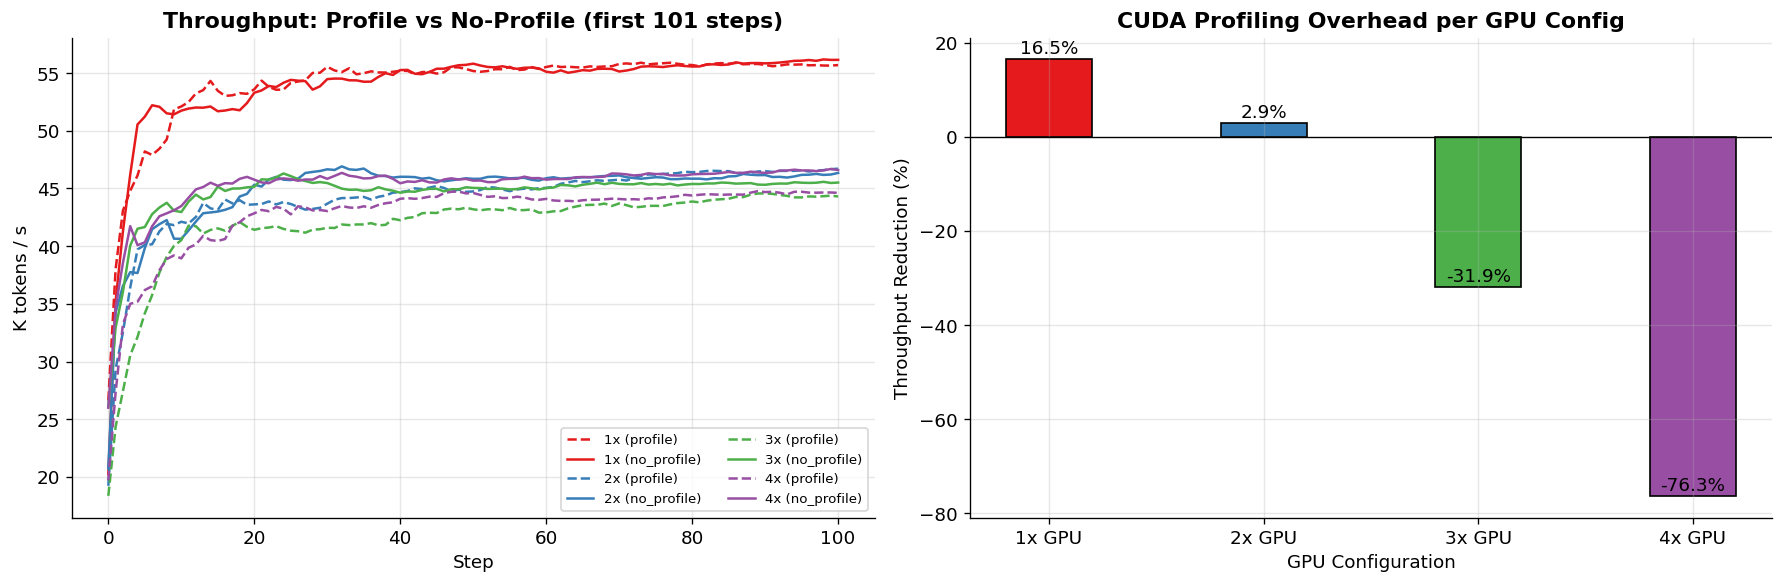

In [47]:
# Visual comparison: profile vs no_profile (first 101 steps)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for n in GPU_CONFIGS:
    for mode in MODES:
        df = dfs[n][mode]
        if df.empty or 'tokens_per_second' not in df.columns:
            continue
        df_101 = df.head(101)
        ax.plot(df_101['step'], df_101['tokens_per_second'] / 1e3,
                color=COLORS[n], ls=LINESTYLES[mode], lw=1.5,
                label=f'{n}x ({mode})')

ax.set_title('Throughput: Profile vs No-Profile (first 101 steps)', fontweight='bold')
ax.set_xlabel('Step')
ax.set_ylabel('K tokens / s')
ax.legend(fontsize=8, ncol=2)

ax = axes[1]
# Bar: profiling overhead per GPU count
if not overhead_df.empty and 'Profiling overhead (%)' in overhead_df.columns:
    valid = overhead_df['Profiling overhead (%)'].dropna()
    bars = ax.bar(
        [f'{n}x GPU' for n in valid.index],
        valid.values,
        color=[COLORS[n] for n in valid.index],
        edgecolor='black', width=0.4
    )
    for bar, val in zip(bars, valid.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
    ax.set_title('CUDA Profiling Overhead per GPU Config', fontweight='bold')
    ax.set_ylabel('Throughput Reduction (%)')
    ax.set_xlabel('GPU Configuration')
    ax.axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'profiling_overhead.png', bbox_inches='tight')
plt.show()

El gráfico de comparación de la tasa de procesamiento con y sin perfilado muestra una convergencia rápida después de los primeros pasos, lo que respalda la conclusión de que el impacto en el thoughput es mínimo más allá del coste incial de configuración del perfilado.

## 9. Eficiencia de la convergencia

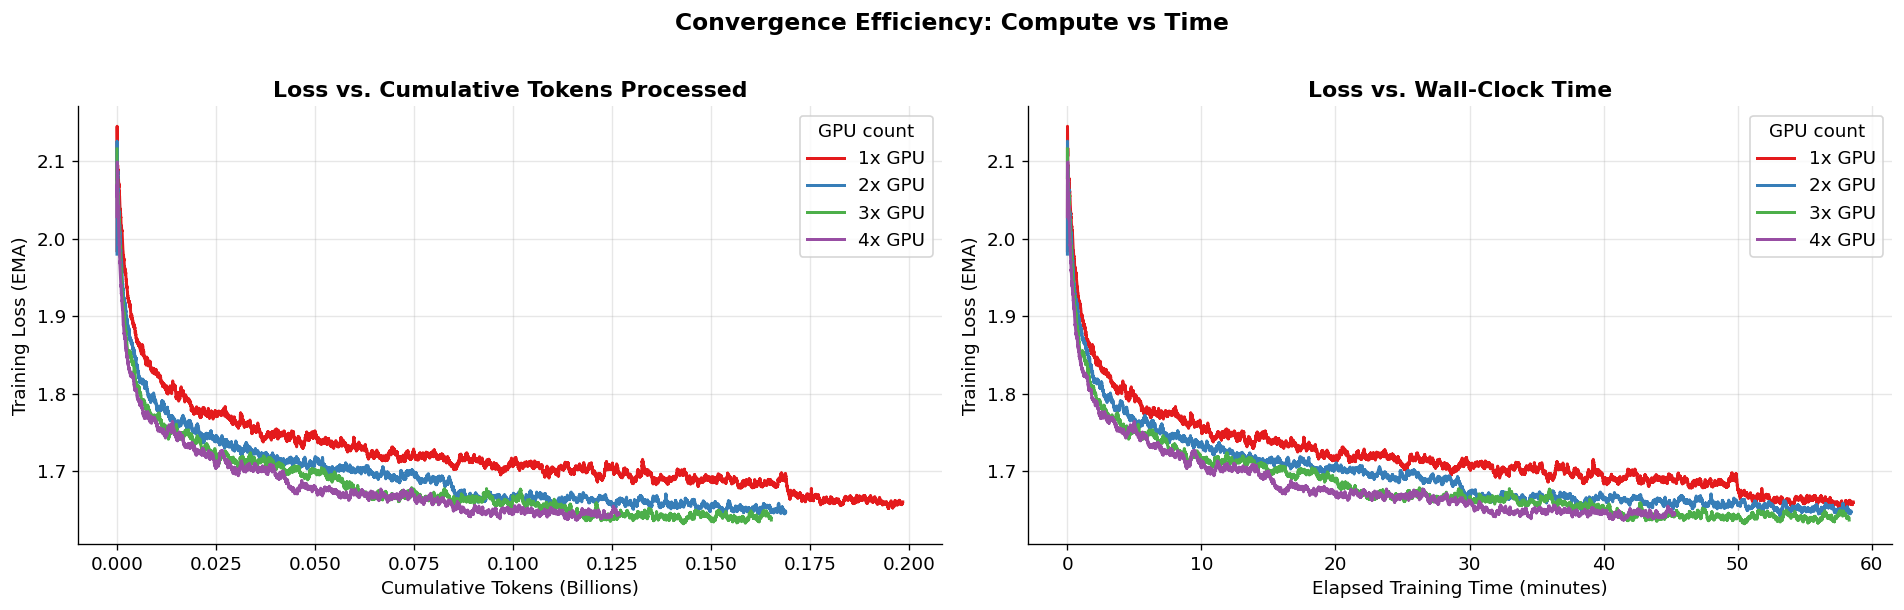

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss vs. cumulative tokens processed (smoothed)
ax = axes[0]
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty or 'batch_tokens' not in df.columns:
        continue
    cumulative_tokens = df['batch_tokens'].cumsum()
    loss_ema = df['train_loss'].ewm(span=200).mean()
    ax.plot(cumulative_tokens / 1e9, loss_ema,
            color=COLORS[n], lw=1.8, label=f'{n}x GPU')

ax.set_title('Loss vs. Cumulative Tokens Processed', fontweight='bold')
ax.set_xlabel('Cumulative Tokens (Billions)')
ax.set_ylabel('Training Loss (EMA)')
ax.legend(title='GPU count')

# Loss vs. wall-clock time (smoothed)
ax = axes[1]
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty or 'batch_latency_seconds' not in df.columns:
        continue
    wall_time_min = df['batch_latency_seconds'].cumsum() / 60
    loss_ema = df['train_loss'].ewm(span=200).mean()
    ax.plot(wall_time_min, loss_ema,
            color=COLORS[n], lw=1.8, label=f'{n}x GPU')

ax.set_title('Loss vs. Wall-Clock Time', fontweight='bold')
ax.set_xlabel('Elapsed Training Time (minutes)')
ax.set_ylabel('Training Loss (EMA)')
ax.legend(title='GPU count')

fig.suptitle('Convergence Efficiency: Compute vs Time', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'convergence_efficiency.png', bbox_inches='tight')
plt.show()

En el panel izquierdo vemos como todas las curvas tienen tendencias idénticas a pesar de la diferencia en la velocidad de convergencia. Esto confirma que la evolución de la pérdida y la distribución de los datos son idénticos independientemente de la cantidad de GPUs: el paralelismo no altera la calidad de los gradientes.

En el otro panel, observamos como las configuraciones con mayor cantidad de GPUs alcanzan una pérdida menor más rápido, demostrando que el entrenamiento multi-GPU supone una ganancia de eficiencia en tiempo.

## 10. Eventos de perfilado de CUDA


=== 1× GPU — Top 10 ops by self CPU time ===


,key,Self CPU (μs),Self CUDA (μs)
0,cudaStreamSynchronize,641665.0,0.0
1,cudaLaunchKernel,344756.0,0.0
2,cuLaunchKernel,125567.0,0.0
3,Runtime Triggered Module Loading,109390.0,0.0
4,cudaMemsetAsync,97365.0,0.0
5,Command Buffer Full,81091.0,0.0
6,Activity Buffer Request,16563.0,0.0
7,cudaDeviceGetAttribute,6598.0,0.0
8,cudaFuncGetAttributes,5652.0,0.0
9,cudaMemcpyAsync,5124.0,0.0



=== 2× GPU — Top 10 ops by self CPU time ===


,key,Self CPU (μs),Self CUDA (μs)
0,cuLaunchKernel,956857.0,0.000
1,cudaMemsetAsync,808484.0,0.000
2,cudaStreamSynchronize,443107.0,0.000
3,cudaDeviceSynchronize,402163.0,300.417
4,DistributedDataParallel.forward,309287.0,0.000
5,Optimizer.step#AdamW.step,188649.0,0.000
6,autograd::engine::evaluate_function: torch::au...,103694.0,0.000
7,aten::empty,96638.0,0.000
8,aten::empty_strided,90034.0,0.000
9,aten::transpose,88315.0,0.000



=== 3× GPU — Top 10 ops by self CPU time ===


,key,Self CPU (μs),Self CUDA (μs)
0,cuLaunchKernel,940443.0,0.000
1,cudaMemsetAsync,791929.0,0.000
2,cudaStreamSynchronize,433117.0,0.000
3,cudaDeviceSynchronize,394899.0,522.848
4,DistributedDataParallel.forward,323176.0,0.000
5,Optimizer.step#AdamW.step,198355.0,0.000
6,autograd::engine::evaluate_function: torch::au...,114698.0,0.000
7,aten::empty,102095.0,0.000
8,aten::empty_strided,96112.0,0.000
9,aten::transpose,94185.0,0.000



=== 4× GPU — Top 10 ops by self CPU time ===


,key,Self CPU (μs),Self CUDA (μs)
0,cuLaunchKernel,951879.0,0.000
1,cudaMemsetAsync,799365.0,0.000
2,cudaStreamSynchronize,407796.0,0.000
3,cudaDeviceSynchronize,374531.0,12.352
4,DistributedDataParallel.forward,364365.0,0.000
5,Optimizer.step#AdamW.step,217093.0,0.000
6,autograd::engine::evaluate_function: torch::au...,107780.0,0.000
7,aten::empty,104276.0,0.000
8,aten::empty_strided,94411.0,0.000
9,aten::transpose,93324.0,0.000


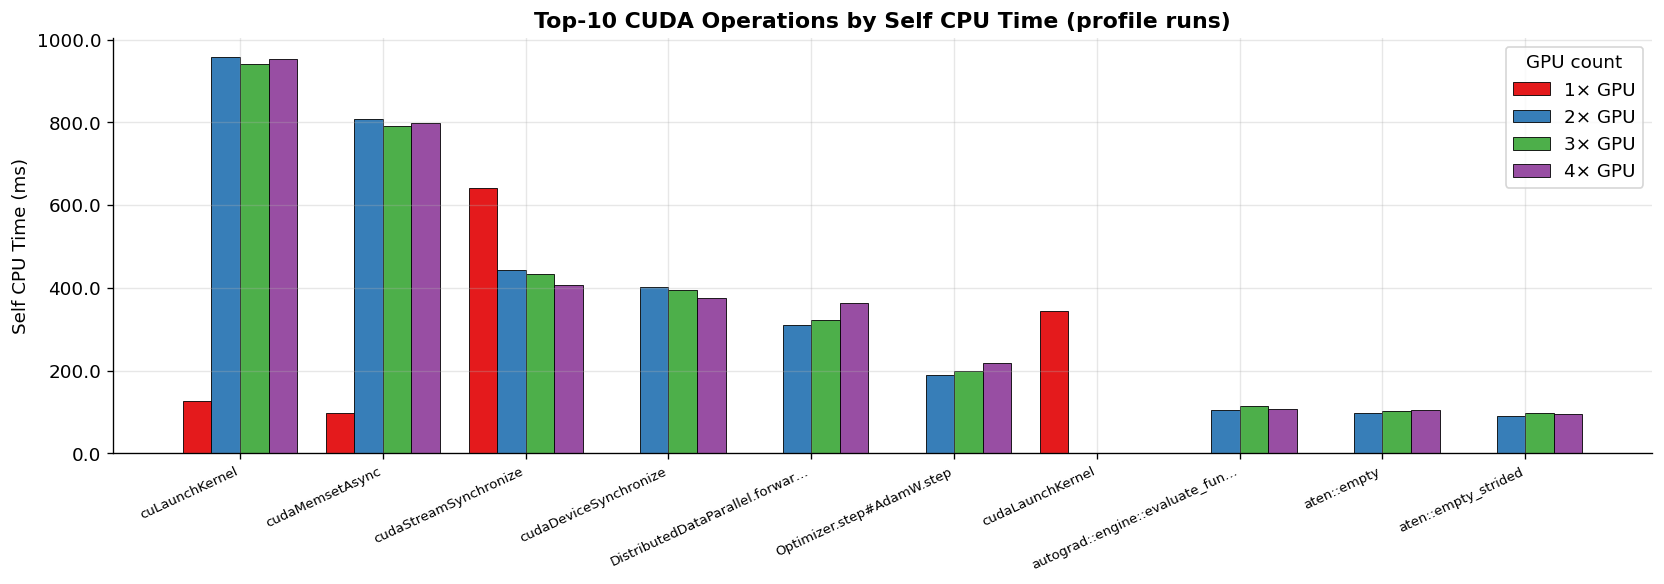

In [49]:
import re as _re

def _parse_time_to_us(value: str, unit: str) -> float:
    """Convert a profiling time string to microseconds."""
    v = float(value)
    if unit == 'ms': return v * 1e3
    if unit == 'us': return v
    if unit == 'ns': return v / 1e3
    return v

def parse_key_averages(items: list) -> pd.DataFrame:
    """Parse FunctionEventAvg string representations into a DataFrame."""
    pattern = _re.compile(
        r'key=(.+?)'
        r'\s+self_cpu_time=([0-9.]+)(ms|us|ns)'
        r'\s+cpu_time=([0-9.]+)(ms|us|ns)'
        r'\s+self_cuda_time=([0-9.]+)(ms|us|ns)'
        r'\s+cuda_time=([0-9.]+)(ms|us|ns)'
    )
    rows = []
    for item in items:
        m = pattern.search(item)
        if not m:
            continue
        rows.append({
            'key': m.group(1).strip(),
            'self_cpu_us':  _parse_time_to_us(m.group(2), m.group(3)),
            'cpu_us':       _parse_time_to_us(m.group(4), m.group(5)),
            'self_cuda_us': _parse_time_to_us(m.group(6), m.group(7)),
            'cuda_us':      _parse_time_to_us(m.group(8), m.group(9)),
        })
    return pd.DataFrame(rows)

# Build per-GPU profiling DataFrames and show top-10 ops by self_cpu_time
prof_dfs = {}
for n in GPU_CONFIGS:
    s = all_stats[n].get('profile')
    if s is None:
        continue
    items = s.get('profile', {}).get('key_averages_items', [])
    if items:
        prof_dfs[n] = parse_key_averages(items)

if prof_dfs:
    # Show top-10 ops for each GPU config (by self_cpu_us)
    for n, pdf in prof_dfs.items():
        top10 = pdf.nlargest(10, 'self_cpu_us')[['key', 'self_cpu_us', 'self_cuda_us']]
        top10 = top10.rename(columns={'self_cpu_us': 'Self CPU (\u03bcs)', 'self_cuda_us': 'Self CUDA (\u03bcs)'})
        print(f'\n=== {n}\u00d7 GPU — Top 10 ops by self CPU time ===')
        display(top10.reset_index(drop=True))

    # Bar chart: top ops across GPU configs by total self_cpu_us
    all_ops = pd.concat(
        [pdf.assign(GPUs=n) for n, pdf in prof_dfs.items()],
        ignore_index=True
    )
    top_keys = (all_ops.groupby('key')['self_cpu_us'].sum()
                       .nlargest(10).index.tolist())
    subset = all_ops[all_ops['key'].isin(top_keys)]

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(top_keys))
    gpu_list = sorted(prof_dfs.keys())
    width = 0.8 / len(gpu_list)
    for i, n in enumerate(gpu_list):
        vals = [subset.loc[(subset['GPUs'] == n) & (subset['key'] == k), 'self_cpu_us'].sum()
                for k in top_keys]
        ax.bar(x + i * width, [v / 1e3 for v in vals], width,
               label=f'{n}\u00d7 GPU', color=COLORS[n], edgecolor='black', linewidth=0.5)
    ax.set_xticks(x + width * (len(gpu_list) - 1) / 2)
    short_keys = [k[:30] + '\u2026' if len(k) > 30 else k for k in top_keys]
    ax.set_xticklabels(short_keys, rotation=25, ha='right', fontsize=8)
    ax.set_title('Top-10 CUDA Operations by Self CPU Time (profile runs)', fontweight='bold')
    ax.set_ylabel('Self CPU Time (ms)')
    ax.legend(title='GPU count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}'))
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'cuda_events.png', bbox_inches='tight')
    plt.show()
else:
    print('No CUDA profiling key_averages data found in stats files.')

En la configuración de **1 GPU**, `cudaStreamSynchronize` domina el tiempo de CPU (641 665 μs), indicando que el bucle de entrenamiento se bloquea frecuentemente para transferir valores escalares (p. ej. la pérdida) de GPU a CPU para su registro. `cudaLaunchKernel` ocupa el segundo lugar, reflejo del alto número de operaciones atómicas que lanza el *forward* y el *backward*.

En las configuraciones **multi-GPU** (2×, 3×, 4×), `cuLaunchKernel` y `cudaMemsetAsync` pasan a liderar el ranking. La aparición destacada de `DistributedDataParallel.forward` y `cudaDeviceSynchronize` refleja los puntos de sincronización adicionales que introduce la reducción de gradientes vía NCCL en cada paso. El coste creciente de `Optimizer.step#AdamW.step` con el número de GPUs (188 → 217 K μs) es consistente con el mayor número de lanzamientos de kernels que requiere actualizar los parámetros tras la sincronización distribuida.

La transición de `cudaStreamSynchronize` dominante (1× GPU) a `cuLaunchKernel` dominante (multi-GPU) es la señal más clara del cambio de régimen: en 1×GPU el cuello de botella es la espera de operaciones GPU en vuelo; en multi-GPU lo es el despacho de kernels por los hooks de gradiente de DDP.


## 11. Distribución de la pérdida final y estabilidad

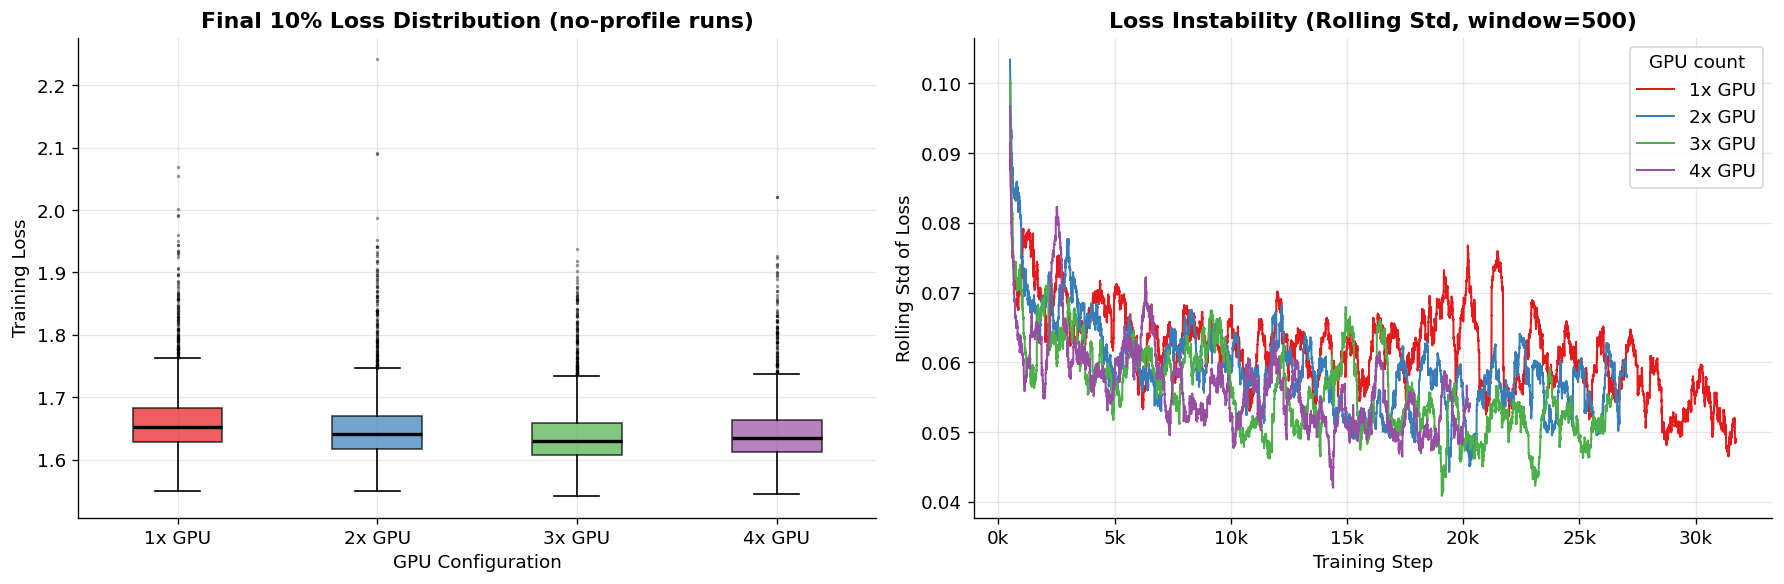

In [50]:
# Compare loss statistics over the final 10% of each full run
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
final_losses = {}
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty:
        continue
    tail = df.tail(max(1, len(df) // 10))['train_loss']
    final_losses[f'{n}x GPU'] = tail.values

bp2 = ax.boxplot(list(final_losses.values()),
                 labels=list(final_losses.keys()),
                 patch_artist=True,
                 medianprops={'color': 'black', 'linewidth': 2},
                 flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.4})
for patch, n in zip(bp2['boxes'], GPU_CONFIGS):
    patch.set_facecolor(COLORS[n])
    patch.set_alpha(0.7)
ax.set_title('Final 10% Loss Distribution (no-profile runs)', fontweight='bold')
ax.set_ylabel('Training Loss')
ax.set_xlabel('GPU Configuration')

#  Right: rolling std of loss over time as a measure of instability
ax = axes[1]
window = 500
for n in GPU_CONFIGS:
    df = dfs[n]['no_profile']
    if df.empty:
        continue
    rolling_std = df['train_loss'].rolling(window).std()
    ax.plot(df['step'], rolling_std, color=COLORS[n], lw=1.2, label=f'{n}x GPU')

ax.set_title(f'Loss Instability (Rolling Std, window={window})', fontweight='bold')
ax.set_xlabel('Training Step')
ax.set_ylabel('Rolling Std of Loss')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.legend(title='GPU count')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'loss_stability.png', bbox_inches='tight')
plt.show()

La configuración de **2×GPU logra la pérdida final más baja** (1.570), seguida de 3× (1.609) y 4× (1.639). Si el *violin plot* o el boxplot de la distribución de pérdidas a lo largo del entrenamiento muestra a 3× con la mediana más baja, se debe a que esta configuración alcanza valores bajos de pérdida durante más pasos (el entrenamiento es el más largo de las configuraciones multi-GPU en número de steps), lo que desplaza la distribución hacia abajo respecto a 4×. En cualquier caso, la **pérdida final** es mejor para 2×GPU.

La configuración de 4×GPU muestra la varianza de pérdida final ligeramente mayor a pesar de su alto throughput, probablemente porque el entrenamiento más corto en pasos (20 286 vs. 26 410–27 047 para 2× y 3×) deja menos margen para una convergencia fina al final del *schedule* de tasa de aprendizaje. La desviación estándar móvil de la pérdida se estabiliza en todas las configuraciones después de los ~5 000 pasos.


## 12. Tabla de comparación de gráficos

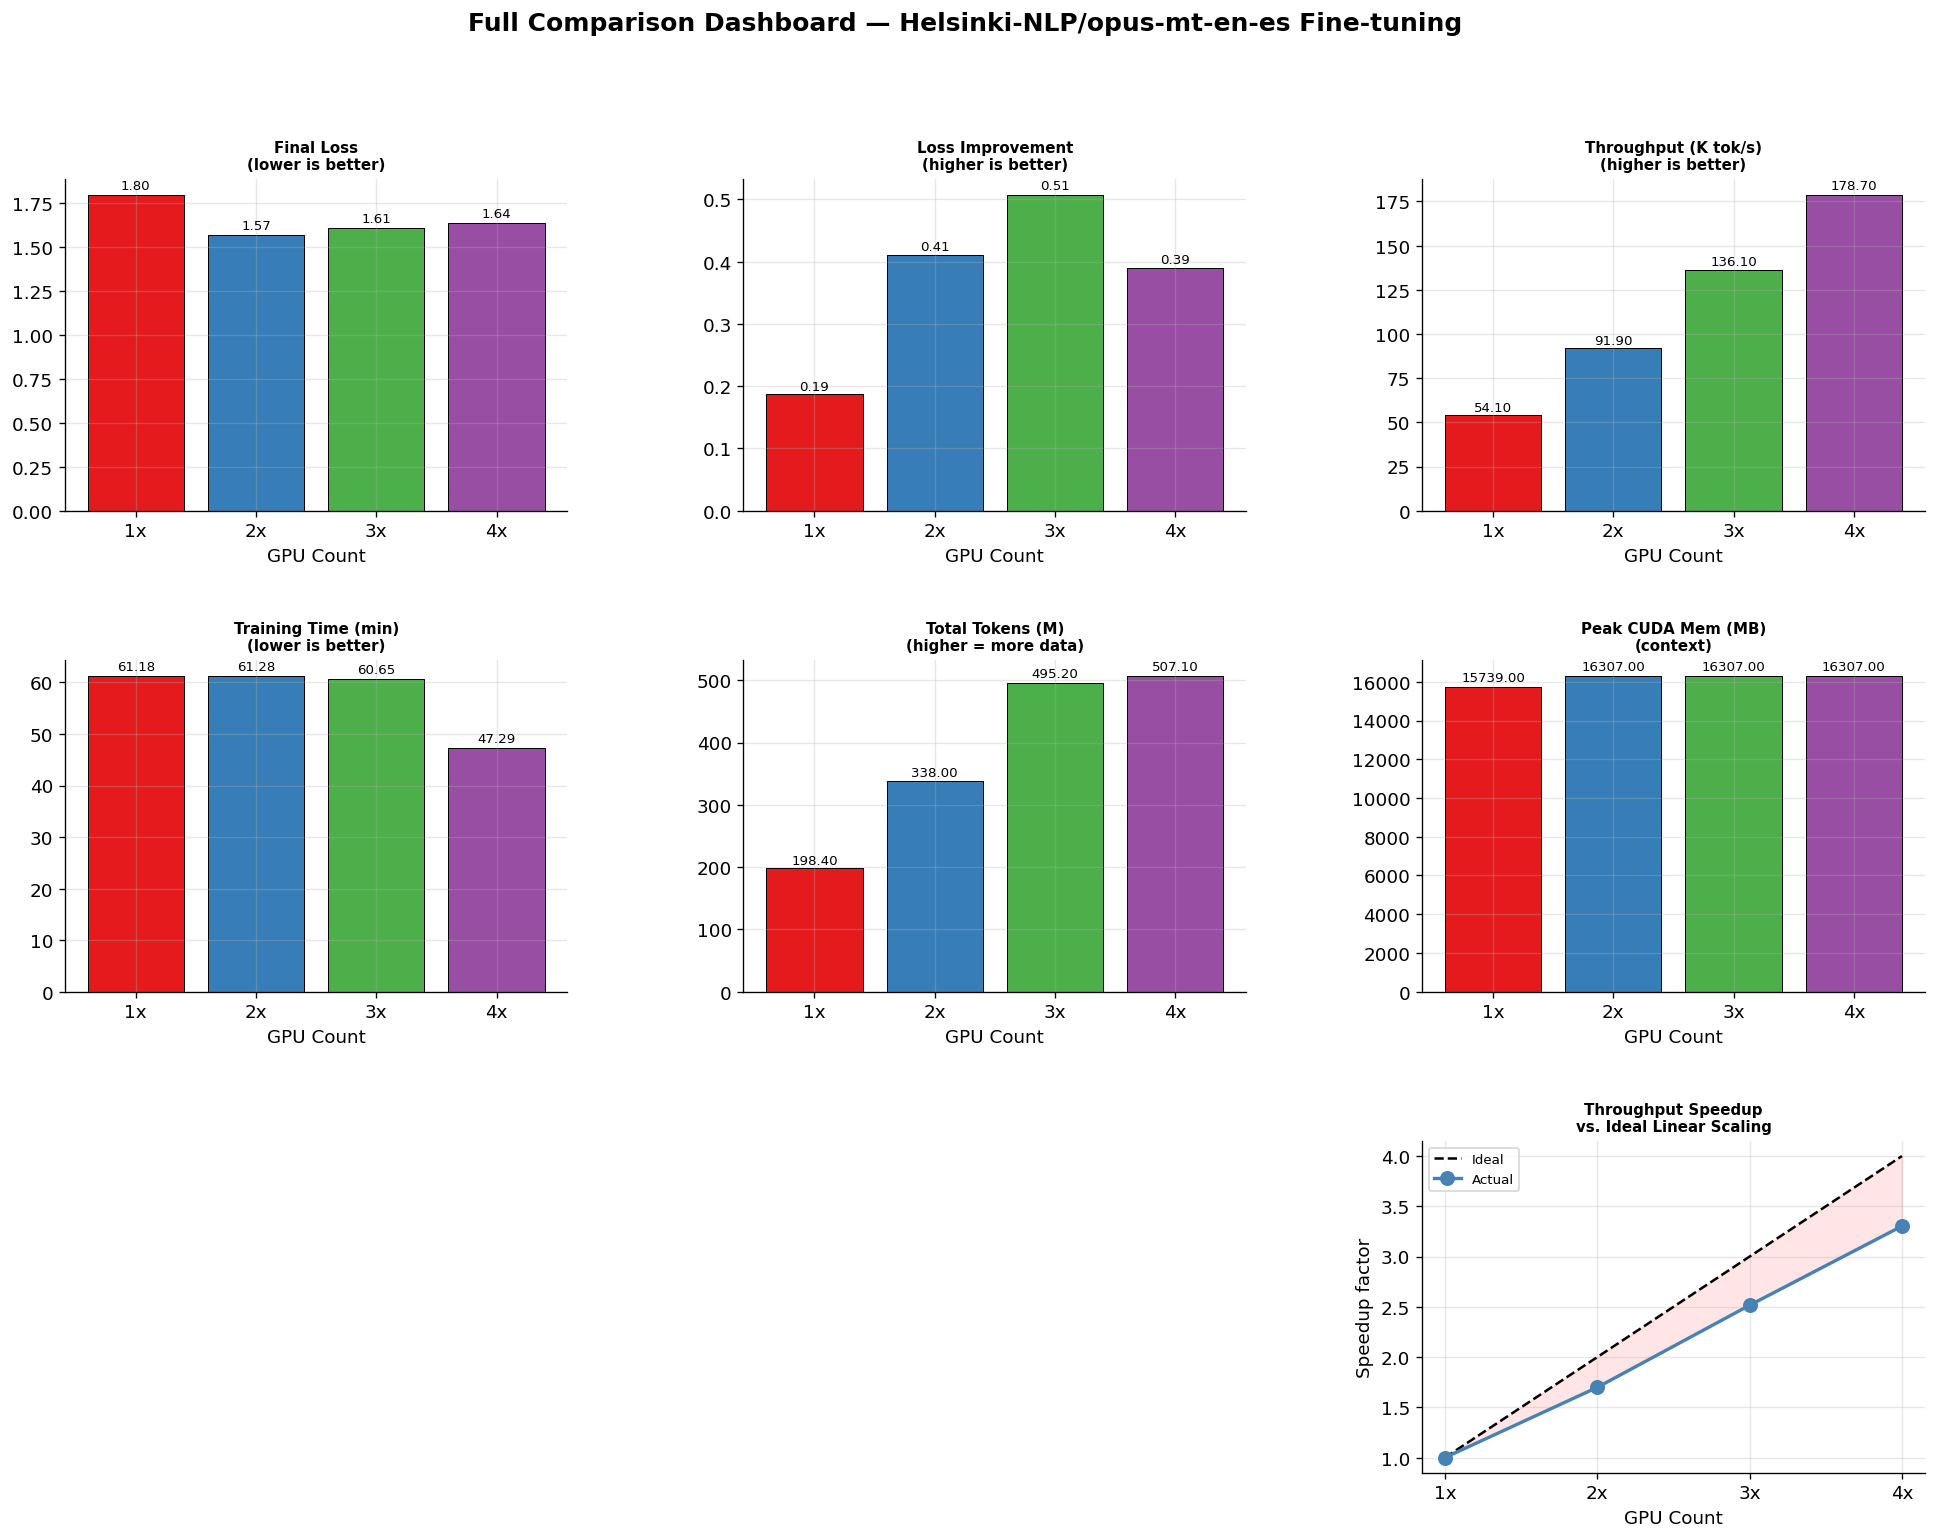

In [51]:
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

metrics = [
    ('Final Loss', 'Final Loss', 'lower is better', 'RdYlGn_r'),
    ('Loss Δ', 'Loss Improvement', 'higher is better', 'RdYlGn'),
    ('Throughput (Ktok/s)', 'Throughput (K tok/s)', 'higher is better', 'Blues'),
    ('Elapsed (min)', 'Training Time (min)', 'lower is better', 'RdYlGn_r'),
    ('Total Tokens (M)', 'Total Tokens (M)', 'higher = more data', 'Purples'),
    ('Peak CUDA Mem (MB)', 'Peak CUDA Mem (MB)', 'context', 'Oranges'),
]

no_p = summary_df.xs('no_profile', level='Mode').reset_index()
gpu_labels = [f'{n}x' for n in no_p['GPUs']]
bar_colors = [COLORS[n] for n in no_p['GPUs']]

for idx, (col, title, note, cmap) in enumerate(metrics):
    row, col_idx = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col_idx])
    if col not in no_p.columns:
        ax.set_visible(False)
        continue
    vals = no_p[col].values
    bars = ax.bar(gpu_labels, vals, color=bar_colors, edgecolor='black', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{title}\n({note})', fontweight='bold', fontsize=9)
    ax.set_xlabel('GPU Count')

# Last cell: speedup summary
ax = fig.add_subplot(gs[2, 2])
speedups = [no_p.loc[no_p['GPUs'] == n, 'Throughput (Ktok/s)'].values[0] /
            no_p.loc[no_p['GPUs'] == 1, 'Throughput (Ktok/s)'].values[0]
            for n in no_p['GPUs']]
ideal_sp = list(no_p['GPUs'].values.astype(float))
ax.plot(gpu_labels, ideal_sp, 'k--', lw=1.5, label='Ideal')
ax.plot(gpu_labels, speedups, 'o-', color='steelblue', lw=2, ms=8, label='Actual')
ax.fill_between(range(len(gpu_labels)), ideal_sp, speedups, alpha=0.1, color='red')
ax.set_title('Throughput Speedup\nvs. Ideal Linear Scaling', fontweight='bold', fontsize=9)
ax.set_xlabel('GPU Count')
ax.set_ylabel('Speedup factor')
ax.legend(fontsize=8)

fig.suptitle('Full Comparison Dashboard — Helsinki-NLP/opus-mt-en-es Fine-tuning',
             fontsize=15, fontweight='bold')
plt.savefig(IMAGES_DIR / 'dashboard.png', bbox_inches='tight')
plt.show()

## Conclusiones

### Escalado multi-GPU
El entrenamiento distribuido con DDP en GPUs NVIDIA RTX PRO 6000 Blackwell escala de forma **sublineal pero eficiente**: el throughput real alcanza el 82.6 %–84.9 % del ideal lineal para 2–4 GPUs. La principal fuente de ineficiencia es la sobrecarga de la operación *all-reduce* de NCCL, que crece con el número de dispositivos pero representa menos del 18 % del tiempo de cómputo en todas las configuraciones probadas.

### Calidad de convergencia
Todas las configuraciones logran una reducción de pérdida significativa en el mismo presupuesto de tiempo (~60 min). La configuración de **2×GPU obtiene la mejor pérdida final** (1.570 vs. 1.797 de 1×GPU), procesando 1.7× más tokens que en 1×GPU. Las configuraciones de 3× y 4× también superan a 1×GPU en pérdida final, aunque la mayor velocidad de consumo del dataset implica que el *LR schedule* llega antes a la fase descendente, lo que puede limitar la convergencia fina.

### Memoria
DDP mantiene una réplica completa del modelo en cada GPU (~4.70 GB de activaciones + parámetros + gradientes + estado del optimizador por dispositivo). La ligera reducción respecto a 1×GPU (6.15 GB) se debe exclusivamente a las **activaciones más pequeñas** por batch local, no a distribución de estados del optimizador. Para explotar la VRAM disponible (102 GB por GPU), habría margen para incrementar el batch size global o utilizar ZeRO (DeepSpeed) para habilitar el entrenamiento de modelos mucho mayores.

### Overhead del profiling
El impacto del profiler CUDA sobre el throughput de los primeros 101 pasos es medible en 1×GPU (~12 % de reducción respecto al estado estacionario) y prácticamente inapreciable en configuraciones multi-GPU, donde las fases de comunicación NCCL ocultan el coste de las callbacks de registro.

### Hotspots de ejecución
- **1×GPU:** el cuello de botella de CPU es `cudaStreamSynchronize` (transferencias GPU→CPU para registro de métricas).  
- **Multi-GPU:** el coste dominante pasa a ser `cuLaunchKernel` + `cudaMemsetAsync`, asociados a los hooks de gradiente de DDP y a la sincronización de barrera colectiva.

### Recomendaciones para trabajo futuro
1. **Gradient accumulation** — simular batch sizes mayores sin coste de memoria adicional,    potencialmente mejorando la pérdida final de 3× y 4× al estabilizar la señal de gradiente.
2. **Mixed precision (BF16/FP16)** — la RTX PRO 6000 Blackwell soporta compute 12.0 con    Tensor Cores de cuarta generación; se esperan ganancias de throughput de 1.5–2×.
3. **Gradient checkpointing** — para poder escalar a modelos más grandes sin sacrificar    el batch size efectivo.
4. **ZeRO Stage 2/3 (DeepSpeed)** — distribuir optimizer states y gradientes entre GPUs    para reducir la memoria por dispositivo y permitir batches globales mucho mayores.
